<a href="https://colab.research.google.com/github/Cho-minjeong/DL_26_01_Team6/blob/main/recycle_project_%EC%8B%9C%EC%97%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
from torchvision import transforms, models
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

demo_model = models.resnet50(weights=None)
num_ftrs = demo_model.fc.in_features
demo_model.fc = nn.Linear(num_ftrs, 6)

save_path = "/content/drive/MyDrive/recycle_project/model_v2.pth"

demo_model.load_state_dict(torch.load(save_path, map_location=device), strict=False)
demo_model = demo_model.to(device)
demo_model.eval()

print("ResNet50 구조로 model_v2.pth 로드 완료!")

Mounted at /content/drive
ResNet50 구조로 model_v2.pth 로드 완료!


시연할 쓰레기 이미지 파일을 업로드해 주세요.


Saving test_10_plastic.jpg to test_10_plastic (1).jpg


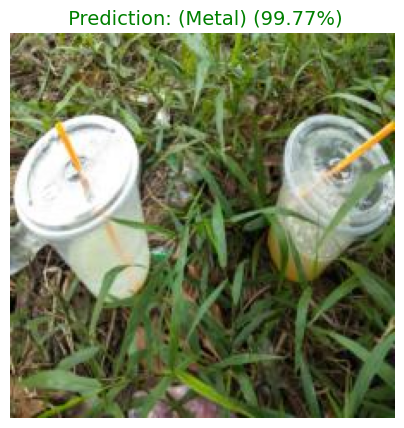

시연할 쓰레기 이미지 파일을 업로드해 주세요.


Saving test_4_plastic.jpg to test_4_plastic (2).jpg


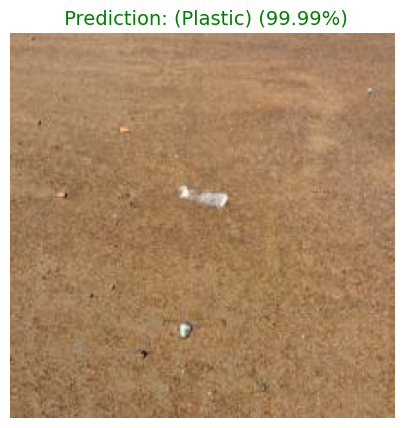

시연할 쓰레기 이미지 파일을 업로드해 주세요.


Saving test_12_trash.jpg to test_12_trash (2).jpg


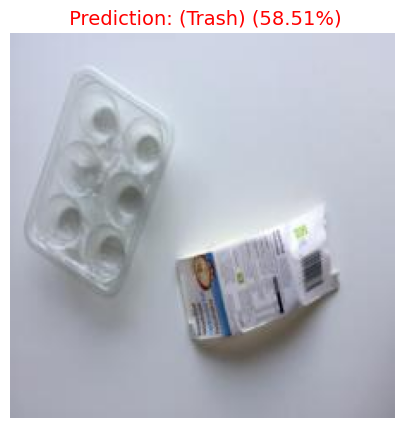

시연할 쓰레기 이미지 파일을 업로드해 주세요.


Saving test_17_metal.jpg to test_17_metal.jpg


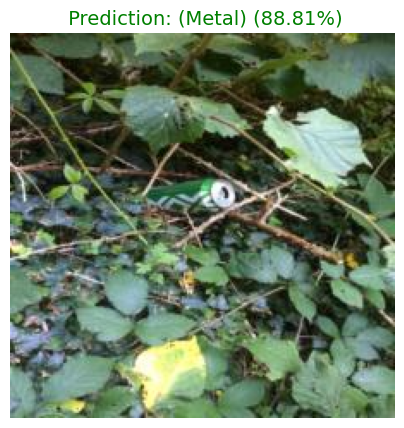

시연할 쓰레기 이미지 파일을 업로드해 주세요.


In [ ]:
from google.colab import output

while True:
    print("시연할 쓰레기 이미지 파일을 업로드해 주세요.")
    uploaded = files.upload()

    if not uploaded:
        print("파일이 업로드되지 않아 시연을 종료합니다.")
        break

    file_name = list(uploaded.keys())[0]
    image = Image.open(file_name).convert('RGB')

    demo_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    input_tensor = demo_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = demo_model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, predicted = torch.max(probabilities, 0)

    class_names = ['(Glass)', '(Paper)', '(Cardboard)',
                   '(Plastic)', '(Metal)', '(Trash)']

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f" Prediction: {class_names[predicted.item()]} ({confidence.item()*100:.2f}%)",
              fontsize=14, color='green' if confidence.item() > 0.6 else 'red')
    plt.show()


    keep_going = output.eval_js('confirm("다른 사진을 추가로 시연하시겠습니까?")')

    if not keep_going:
        print("\n 시연을 성공적으로 마쳤습니다!")
        break

    output.clear(output_tags='📸')